<a href="https://colab.research.google.com/github/tasnim-al/Assignment-mis/blob/main/tasnim_Al_Fori.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install imbalanced-learn

In [ ]:
# Import essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Splitting data
from sklearn.model_selection import train_test_split

# Models
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier

# Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, roc_auc_score

# Handle imbalance
from imblearn.over_sampling import SMOTE

In [ ]:
# Load dataset
data = pd.read_csv('diabetes.csv')

# Show first rows
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# Shape of the dataset
print(data.shape)

(768, 9)


In [ ]:
# Basic statistics
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
# Check data types
print(data.dtypes)

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


In [ ]:
# Check diabetes outcome distribution
outcome_counts = data['Outcome'].value_counts()
print(outcome_counts)

Outcome
0    500
1    268
Name: count, dtype: int64


In [ ]:
# Show percentage distribution
print(data['Outcome'].value_counts(normalize=True) * 100)

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


In [ ]:
# Check for missing values in the dataset
print(data.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
# Replace zero values with median (considered missing in medical data)
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols:
    data[col] = data[col].replace(0, data[col].median())

# Confirm no missing values
print(data.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
# No unnecessary columns to drop in diabetes dataset
# Just confirm dataset shape

print(data.shape)

(768, 9)


In [ ]:
# Handle outliers using IQR method
for col in data.columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data[col] = data[col].clip(lower, upper)

print("Outliers handled successfully")

Outliers handled successfully


In [ ]:
# No categorical columns in diabetes dataset
# All features are numerical

data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148,72,35.0,30.5,33.6,0.627,50.0,1
1,1.0,85,66,29.0,30.5,26.6,0.351,31.0,0
2,8.0,183,64,23.0,30.5,23.3,0.672,32.0,1
3,1.0,89,66,23.0,94.0,28.1,0.167,21.0,0
4,0.0,137,40,35.0,168.0,43.1,1.200,33.0,1


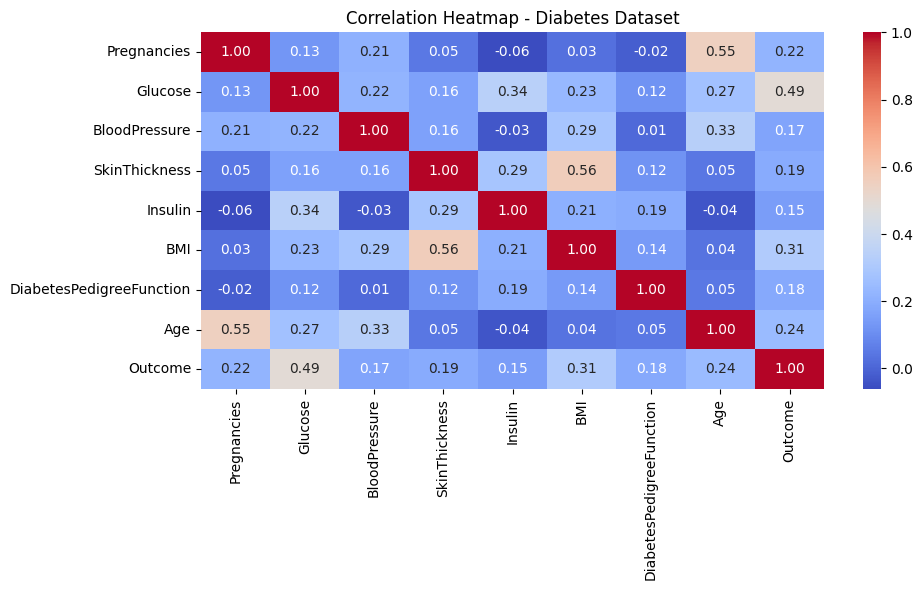

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True, fmt='.2f', cmap='coolwarm')

plt.title('Correlation Heatmap - Diabetes Dataset')
plt.tight_layout()
plt.show()

In [ ]:
# Exploratory Data Analysis (EDA)

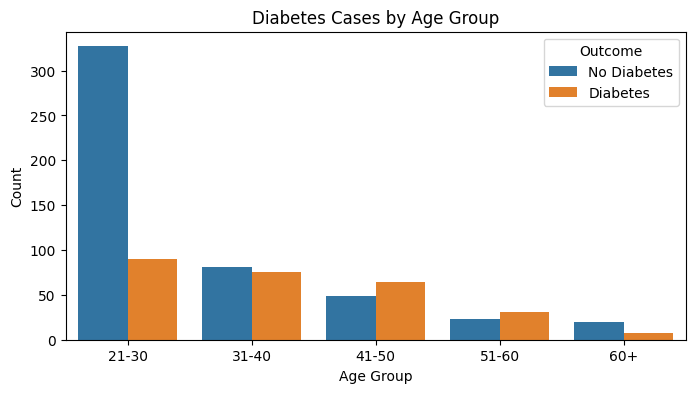

In [ ]:
# Reload dataset for clean visualization
data_viz = pd.read_csv('diabetes.csv')

# Create Age Groups
data_viz['Age_Group'] = pd.cut(data_viz['Age'],
    bins=[20, 30, 40, 50, 60, 100],
    labels=['21-30', '31-40', '41-50', '51-60', '60+'])

# Plot Outcome by Age Group
plt.figure(figsize=(8,4))
sns.countplot(data=data_viz, x='Age_Group', hue='Outcome')
plt.title('Diabetes Cases by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(title='Outcome', labels=['No Diabetes', 'Diabetes'])
plt.show()

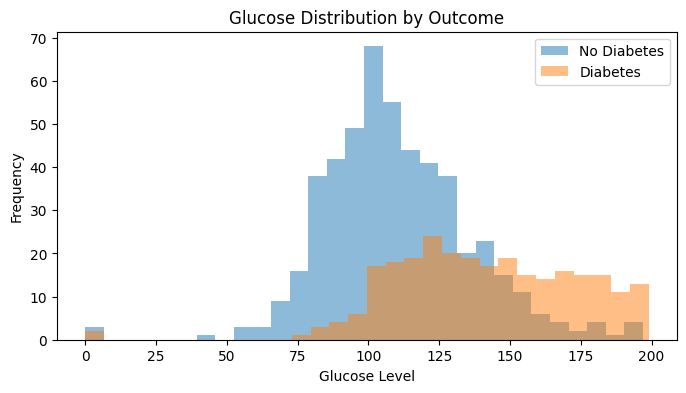

In [ ]:
# Glucose distribution by Outcome
plt.figure(figsize=(8,4))

data_viz[data_viz['Outcome']==0]['Glucose'].plot(
    kind='hist', bins=30, alpha=0.5, label='No Diabetes')

data_viz[data_viz['Outcome']==1]['Glucose'].plot(
    kind='hist', bins=30, alpha=0.5, label='Diabetes')

plt.title('Glucose Distribution by Outcome')
plt.xlabel('Glucose Level')
plt.ylabel('Frequency')
plt.legend()
plt.show()

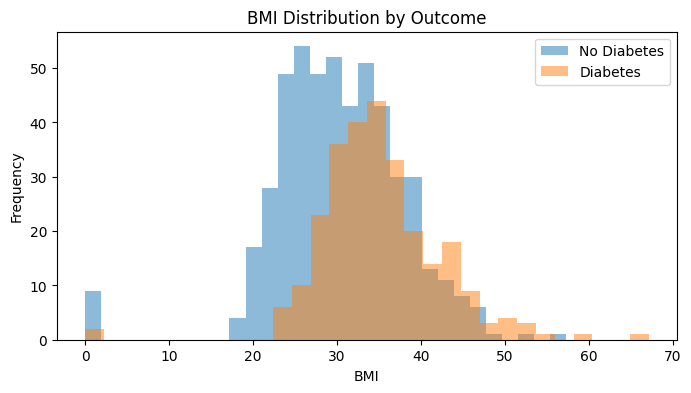

In [ ]:
# BMI distribution by Outcome
plt.figure(figsize=(8,4))

data_viz[data_viz['Outcome']==0]['BMI'].plot(
    kind='hist', bins=30, alpha=0.5, label='No Diabetes')

data_viz[data_viz['Outcome']==1]['BMI'].plot(
    kind='hist', bins=30, alpha=0.5, label='Diabetes')

plt.title('BMI Distribution by Outcome')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [ ]:
# Separate features and target
X = data.drop(columns=['Outcome'])
Y = data['Outcome']

print(X.shape)
print(Y.shape)

(768, 8)
(768,)


In [ ]:
# Split dataset
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.25, random_state=42, stratify=Y)

print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(576, 8)
(192, 8)
(576,)
(192,)


In [ ]:
# Handle class imbalance using SMOTE
sm = SMOTE(random_state=42)
X_train, Y_train = sm.fit_resample(X_train, Y_train)

print(pd.Series(Y_train).value_counts())

Outcome
0    375
1    375
Name: count, dtype: int64


In [ ]:
#  Handle Class Imbalance using SMOTE

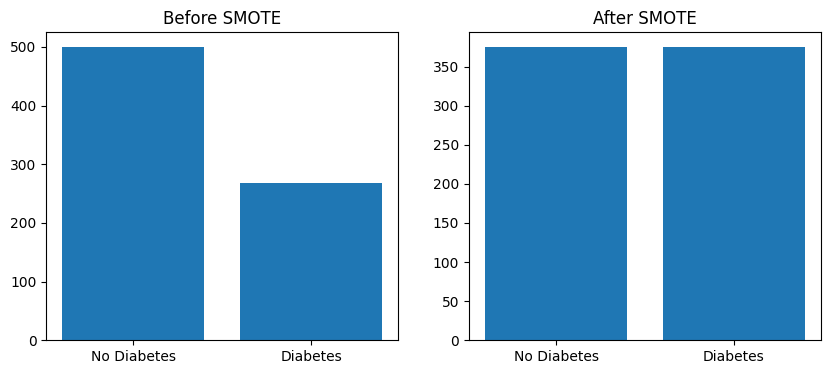

In [ ]:
# Before vs After SMOTE
fig, axes = plt.subplots(1,2, figsize=(10,4))

original = Y.value_counts()
axes[0].bar(['No Diabetes','Diabetes'], [original[0], original[1]])
axes[0].set_title('Before SMOTE')

after = pd.Series(Y_train).value_counts()
axes[1].bar(['No Diabetes','Diabetes'], [after[0], after[1]])
axes[1].set_title('After SMOTE')

plt.show()

In [ ]:
#  Feature Scaling using StandardScaler

In [ ]:
# Feature scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [ ]:
#  Decision Tree Classifier

In [ ]:
# Decision Tree Model
dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42)

dt.fit(X_train, Y_train)

y_pred_dt = dt.predict(X_test)

print(classification_report(Y_test, y_pred_dt))
print(confusion_matrix(Y_test, y_pred_dt))
print("Accuracy:", accuracy_score(Y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.87      0.74      0.80       125
           1       0.62      0.79      0.70        67

    accuracy                           0.76       192
   macro avg       0.75      0.77      0.75       192
weighted avg       0.78      0.76      0.77       192

[[93 32]
 [14 53]]
Accuracy: 0.7604166666666666


In [ ]:
# Cross Validation - Decision Tree

from sklearn.model_selection import cross_val_score

cv_dt = cross_val_score(dt, X, Y, cv=5)

print("Cross Validation Scores (DT):", cv_dt)
print("Mean CV Accuracy (DT):", cv_dt.mean())

Cross Validation Scores (DT): [0.74025974 0.68831169 0.77922078 0.77777778 0.75816993]
Mean CV Accuracy (DT): 0.7487479840421016


In [ ]:
#  Decision Tree - Confusion Matrix Details

In [ ]:
cm_dt = confusion_matrix(Y_test, y_pred_dt)

TN = cm_dt[0][0]
FN = cm_dt[1][0]
FP = cm_dt[0][1]
TP = cm_dt[1][1]

print("TP =", TP)
print("TN =", TN)
print("FP =", FP)
print("FN =", FN)

print("Specificity =", TN/(TN+FP))
print("Sensitivity =", TP/(TP+FN))

TP = 53
TN = 93
FP = 32
FN = 14
Specificity = 0.744
Sensitivity = 0.7910447761194029


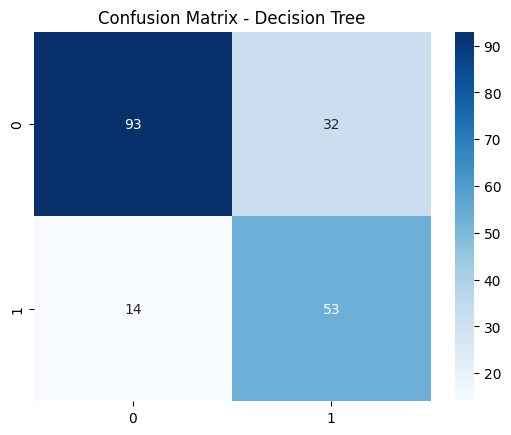

In [ ]:
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

In [ ]:
# Feature Importance from Decision Tree

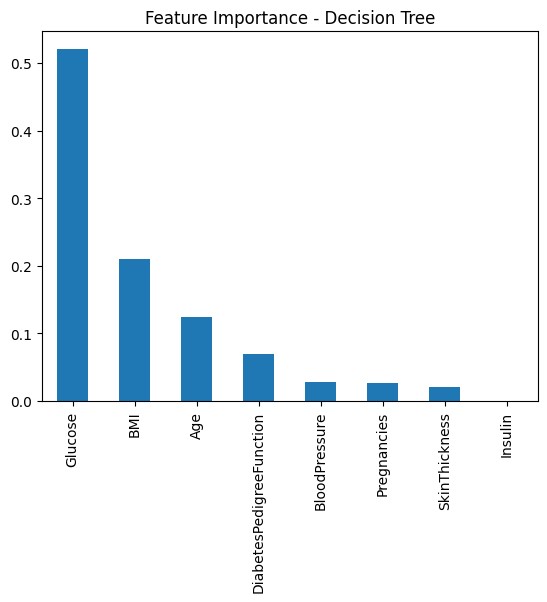

In [ ]:
importances = pd.Series(dt.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).plot(kind='bar')

plt.title('Feature Importance - Decision Tree')
plt.show()

In [ ]:
# Decision Tree Structure - Stroke Prediction

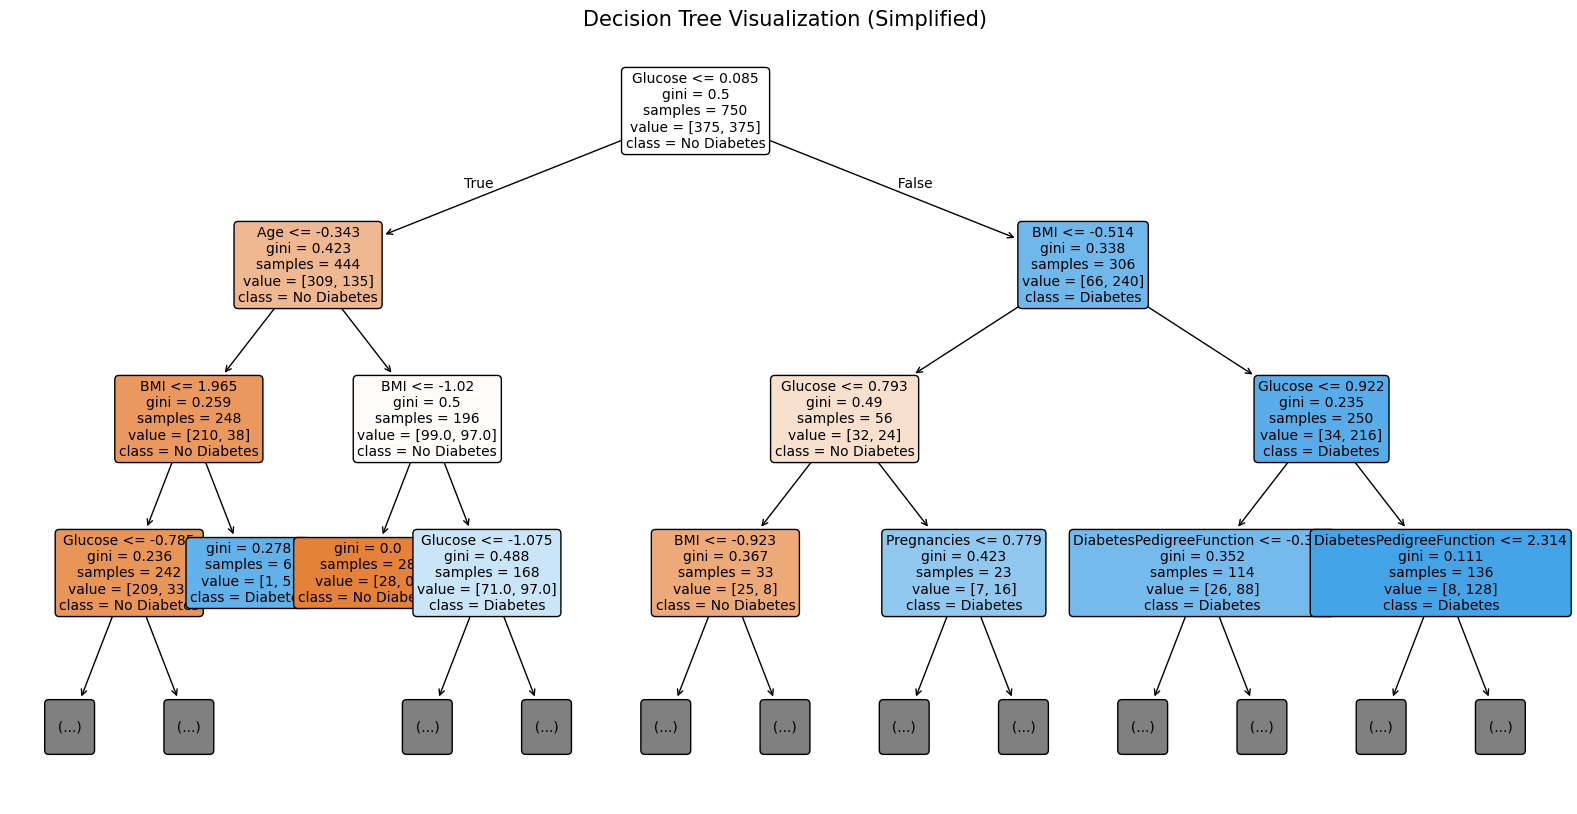

In [ ]:
# Improved Decision Tree Visualization (Clear & Readable)
plt.figure(figsize=(20,10))

plot_tree(dt,
          feature_names=X.columns,
          class_names=['No Diabetes','Diabetes'],
          filled=True,
          rounded=True,
          max_depth=3,
          fontsize=10)

plt.title('Decision Tree Visualization (Simplified)', fontsize=15)
plt.show()

In [ ]:
#  Random Forest Model for Diabetes Prediction

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, Y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print("=== Random Forest Classification Report ===")
print(classification_report(Y_test, y_pred_rf))

print("Confusion Matrix:")
print(confusion_matrix(Y_test, y_pred_rf))

print("Accuracy:", accuracy_score(Y_test, y_pred_rf))

=== Random Forest Classification Report ===
              precision    recall  f1-score   support

           0       0.86      0.76      0.81       125
           1       0.63      0.78      0.70        67

    accuracy                           0.77       192
   macro avg       0.75      0.77      0.75       192
weighted avg       0.78      0.77      0.77       192

Confusion Matrix:
[[95 30]
 [15 52]]
Accuracy: 0.765625


In [ ]:
import joblib
joblib.dump(rf_model, 'random_forest_model.pkl')

['random_forest_model.pkl']

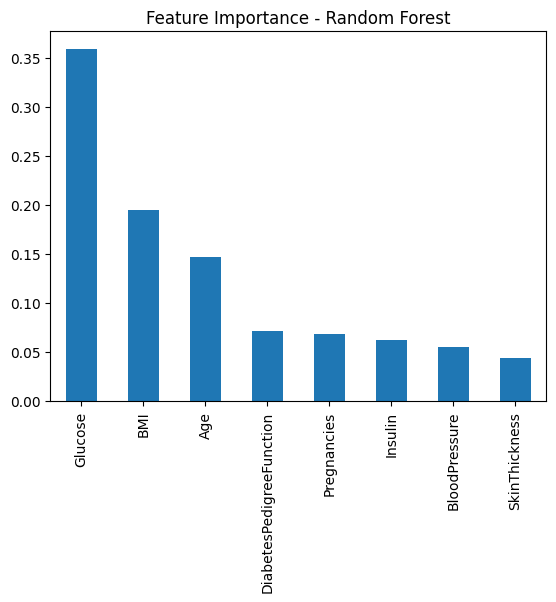

In [ ]:
# Feature Importance - Random Forest

importances_rf = pd.Series(rf_model.feature_importances_, index=X.columns)
importances_rf.sort_values(ascending=False).plot(kind='bar')

plt.title('Feature Importance - Random Forest')
plt.show()

In [ ]:
# Metrics -  Random Forest - Confusion Matrix Details

In [ ]:
import sklearn.metrics as metrics

#  Extract performance metrics

cm_rf = confusion_matrix(Y_test, y_pred_rf)

TN = cm_rf[0][0]
FP = cm_rf[0][1]
FN = cm_rf[1][0]
TP = cm_rf[1][1]

print("TP:", TP)
print("TN:", TN)
print("FP:", FP)
print("FN:", FN)

print("Specificity:", TN / (TN + FP))
print("Sensitivity (Recall):", TP / (TP + FN))

print("Precision:", metrics.precision_score(Y_test, y_pred_rf))
print("F1 Score:", metrics.f1_score(Y_test, y_pred_rf))

TP: 52
TN: 95
FP: 30
FN: 15
Specificity: 0.76
Sensitivity (Recall): 0.7761194029850746
Precision: 0.6341463414634146
F1 Score: 0.697986577181208


In [ ]:
# Visual Confusion Matrix

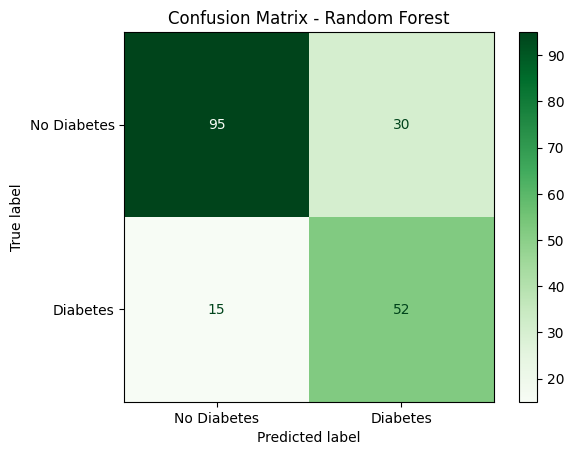

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

#  Confusion matrix heatmap

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=['No Diabetes', 'Diabetes']
)

disp.plot(cmap='Greens')

plt.title("Confusion Matrix - Random Forest")
plt.show()

In [ ]:
#  Compare Decision Tree vs Random Forest vs KNN

In [ ]:
# KNN Model
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, Y_train)
y_pred_knn = knn_model.predict(X_test)

dt_acc  = accuracy_score(Y_test, y_pred_dt)
rf_acc  = accuracy_score(Y_test, y_pred_rf)
knn_acc = accuracy_score(Y_test, y_pred_knn)

print("=== Model Comparison ===")
print("Decision Tree Accuracy:", dt_acc)
print("Random Forest Accuracy:", rf_acc)
print("KNN Accuracy:", knn_acc)

=== Model Comparison ===
Decision Tree Accuracy: 0.7604166666666666
Random Forest Accuracy: 0.765625
KNN Accuracy: 0.7083333333333334


In [ ]:
#  KNN — Finding Best K

Optimal K value: 20


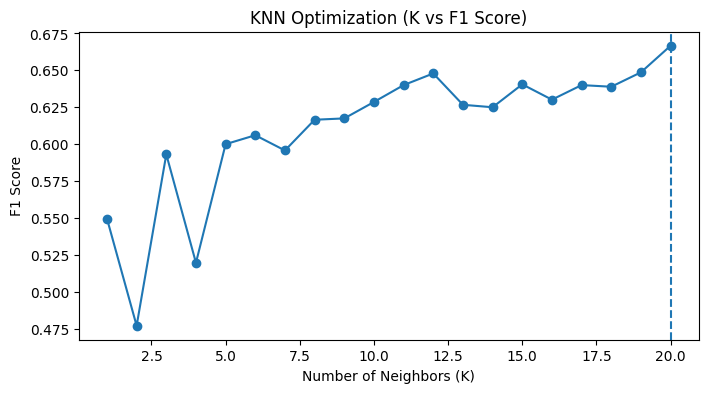

In [ ]:
#  Selecting Optimal K for KNN using F1 Score

from sklearn.metrics import f1_score

k_range = range(1, 21)
f1_list = []

for k in k_range:
    knn_model_temp = KNeighborsClassifier(n_neighbors=k)
    knn_model_temp.fit(X_train, Y_train)
    y_temp_pred = knn_model_temp.predict(X_test)
    score = f1_score(Y_test, y_temp_pred)
    f1_list.append(score)

# Best K
optimal_k = k_range[f1_list.index(max(f1_list))]
print("Optimal K value:", optimal_k)

# Visualization
plt.figure(figsize=(8,4))
plt.plot(k_range, f1_list, marker='o')
plt.axvline(optimal_k, linestyle='--')
plt.title("KNN Optimization (K vs F1 Score)")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("F1 Score")
plt.show()

In [ ]:
#  KNN Model

In [ ]:
#  Final KNN Model

knn_model = KNeighborsClassifier(n_neighbors=optimal_k)

knn_model.fit(X_train, Y_train)

y_pred_knn = knn_model.predict(X_test)

print("=== KNN Classification Report ===")
print(classification_report(Y_test, y_pred_knn))

print("Confusion Matrix:")
print(confusion_matrix(Y_test, y_pred_knn))

print("Accuracy:", accuracy_score(Y_test, y_pred_knn))

=== KNN Classification Report ===
              precision    recall  f1-score   support

           0       0.83      0.77      0.80       125
           1       0.62      0.72      0.67        67

    accuracy                           0.75       192
   macro avg       0.73      0.74      0.73       192
weighted avg       0.76      0.75      0.75       192

Confusion Matrix:
[[96 29]
 [19 48]]
Accuracy: 0.75


In [ ]:
joblib.dump(knn_model, 'knn_model.pkl')

['knn_model.pkl']

In [ ]:
# Cross Validation - KNN
cv_knn = cross_val_score(knn_model, X, Y, cv=5)

print("Cross Validation Scores (KNN):", cv_knn)
print("Mean CV Accuracy (KNN):", cv_knn.mean())

Cross Validation Scores (KNN): [0.74025974 0.66883117 0.75974026 0.79084967 0.73202614]
Mean CV Accuracy (KNN): 0.7383413971649266


In [ ]:
#   Detailed Performance Analysis (KNN)

In [ ]:
cm_knn = confusion_matrix(Y_test, y_pred_knn)

TN = cm_knn[0][0]
FP = cm_knn[0][1]
FN = cm_knn[1][0]
TP = cm_knn[1][1]

print("TP:", TP)
print("TN:", TN)
print("FP:", FP)
print("FN:", FN)

print("Specificity:", TN / (TN + FP))
print("Sensitivity:", TP / (TP + FN))

print("Precision:", metrics.precision_score(Y_test, y_pred_knn))
print("Recall:", metrics.recall_score(Y_test, y_pred_knn))
print("F1 Score:", metrics.f1_score(Y_test, y_pred_knn))

TP: 48
TN: 96
FP: 29
FN: 19
Specificity: 0.768
Sensitivity: 0.7164179104477612
Precision: 0.6233766233766234
Recall: 0.7164179104477612
F1 Score: 0.6666666666666666


In [ ]:
#  KNN Confusion Matrix (Visualization)

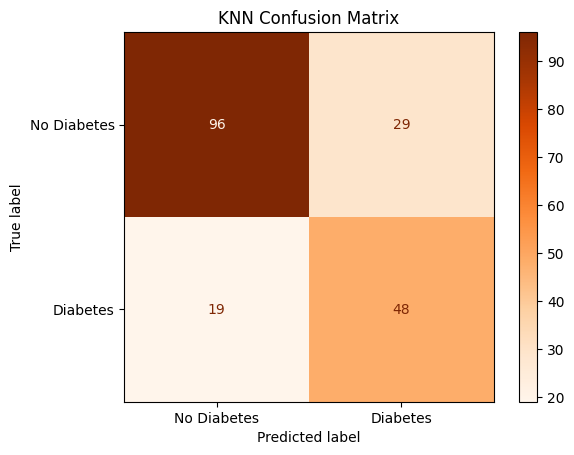

In [ ]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=['No Diabetes', 'Diabetes']
)

disp.plot(cmap='Oranges')

plt.title("KNN Confusion Matrix")
plt.show()

In [ ]:
# ROC Curve Comparison

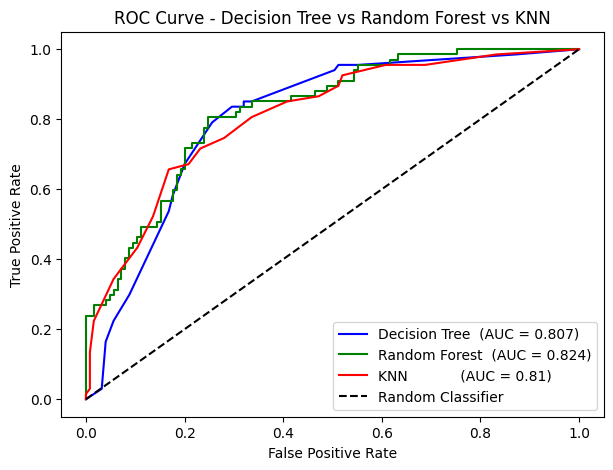

AUC - Decision Tree : 0.8066
AUC - Random Forest : 0.8245
AUC - KNN           : 0.8102


In [ ]:
dt.fit(X_train, Y_train)
# Get probability scores for all 3
y_prob_dt  = dt.predict_proba(X_test)[:, 1]
y_prob_rf  = rf_model.predict_proba(X_test)[:, 1]
y_prob_knn = knn_model.predict_proba(X_test)[:, 1]

# Calculate ROC curves for all 3
fpr_dt,  tpr_dt,  _ = roc_curve(Y_test, y_prob_dt)
fpr_rf,  tpr_rf,  _ = roc_curve(Y_test, y_prob_rf)
fpr_knn, tpr_knn, _ = roc_curve(Y_test, y_prob_knn)

# AUC scores
auc_dt  = roc_auc_score(Y_test, y_prob_dt)
auc_rf  = roc_auc_score(Y_test, y_prob_rf)
auc_knn = roc_auc_score(Y_test, y_prob_knn)

# Plot all 3 ROC curves together
plt.figure(figsize=(7, 5))
plt.plot(fpr_dt,  tpr_dt,
         label='Decision Tree  (AUC = ' + str(round(auc_dt,  3)) + ')',
         color='blue')
plt.plot(fpr_rf,  tpr_rf,
         label='Random Forest  (AUC = ' + str(round(auc_rf,  3)) + ')',
         color='green')
plt.plot(fpr_knn, tpr_knn,
         label='KNN            (AUC = ' + str(round(auc_knn, 3)) + ')',
         color='red')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree vs Random Forest vs KNN')
plt.legend()
plt.show()

print('AUC - Decision Tree :', round(auc_dt,  4))
print('AUC - Random Forest :', round(auc_rf,  4))
print('AUC - KNN           :', round(auc_knn, 4))

In [ ]:
#  Side-by-Side Confusion Matrices

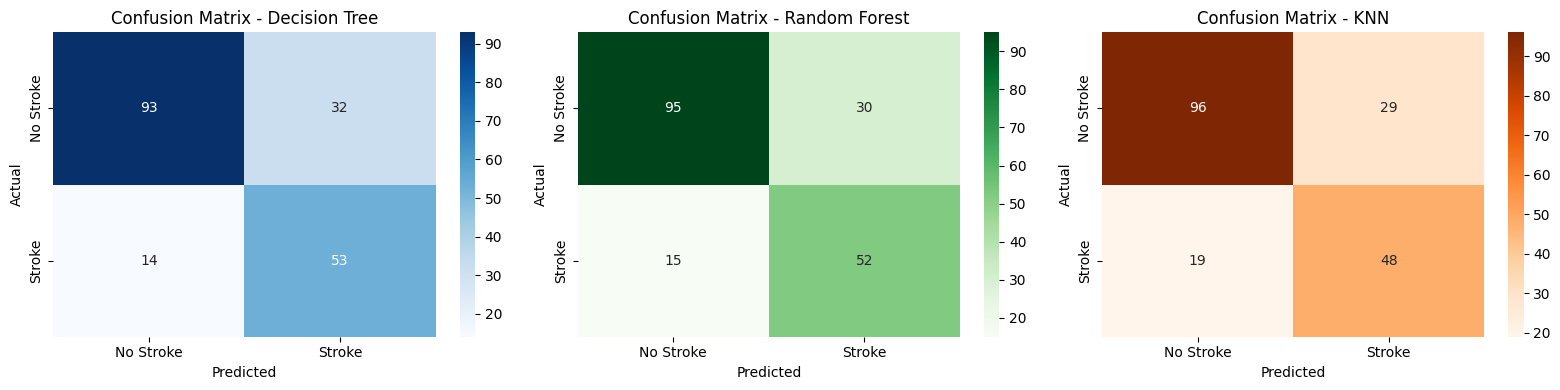

In [ ]:
# Side by Side Confusion Matrix - DT vs Random Forest vs KNN
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.heatmap(confusion_matrix(Y_test, y_pred_dt),
            annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Stroke', 'Stroke'],
            yticklabels=['No Stroke', 'Stroke'])
axes[0].set_title('Confusion Matrix - Decision Tree')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(Y_test, y_pred_rf),
            annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No Stroke', 'Stroke'],
            yticklabels=['No Stroke', 'Stroke'])
axes[1].set_title('Confusion Matrix - Random Forest')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

sns.heatmap(confusion_matrix(Y_test, y_pred_knn),
            annot=True, fmt='d', cmap='Oranges', ax=axes[2],
            xticklabels=['No Stroke', 'Stroke'],
            yticklabels=['No Stroke', 'Stroke'])
axes[2].set_title('Confusion Matrix - KNN')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [ ]:
# Final Model Comparison - Final Comparison Table

In [ ]:
dt_acc  = accuracy_score(Y_test, y_pred_dt)
rf_acc  = accuracy_score(Y_test, y_pred_rf)
knn_acc = accuracy_score(Y_test, y_pred_knn)

dt_f1  = metrics.f1_score(Y_test, y_pred_dt)
rf_f1  = metrics.f1_score(Y_test, y_pred_rf)
knn_f1 = metrics.f1_score(Y_test, y_pred_knn)

print("===== Final Results =====")
print("Decision Tree  → Accuracy:", dt_acc, "F1:", dt_f1)
print("Random Forest  → Accuracy:", rf_acc, "F1:", rf_f1)
print("KNN            → Accuracy:", knn_acc, "F1:", knn_f1)

===== Final Results =====
Decision Tree  → Accuracy: 0.7604166666666666 F1: 0.6973684210526315
Random Forest  → Accuracy: 0.765625 F1: 0.697986577181208
KNN            → Accuracy: 0.75 F1: 0.6666666666666666


In [ ]:
#  Bar Chart Comparison

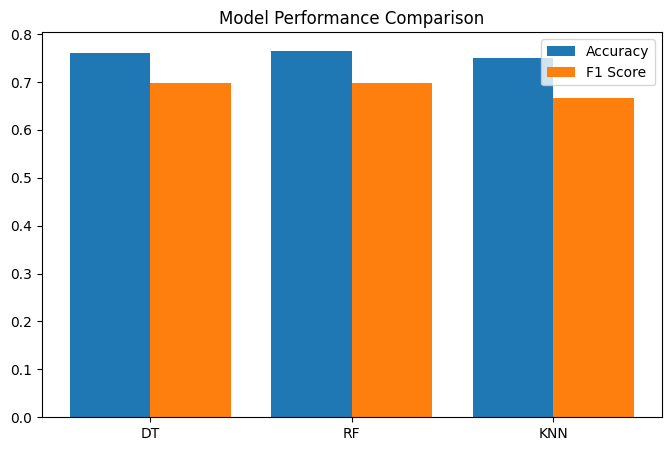

In [ ]:
# Visual Comparison Chart

models = ['DT', 'RF', 'KNN']
accuracy = [dt_acc, rf_acc, knn_acc]
f1_scores = [dt_f1, rf_f1, knn_f1]

x = np.arange(len(models))

plt.figure(figsize=(8,5))
plt.bar(x - 0.2, accuracy, 0.4, label='Accuracy')
plt.bar(x + 0.2, f1_scores, 0.4, label='F1 Score')

plt.xticks(x, models)
plt.title("Model Performance Comparison")
plt.legend()
plt.show()

========== Final Comparison ==========
Metric            Decision Tree   Random Forest        KNN
---------------------------------------------------------
Accuracy                 0.7604          0.7656     0.7500
Precision                0.6235          0.6341     0.6234
Recall                   0.7910          0.7761     0.7164
F1 Score                 0.6974          0.6980     0.6667
AUC Score                0.8066          0.8245     0.8102


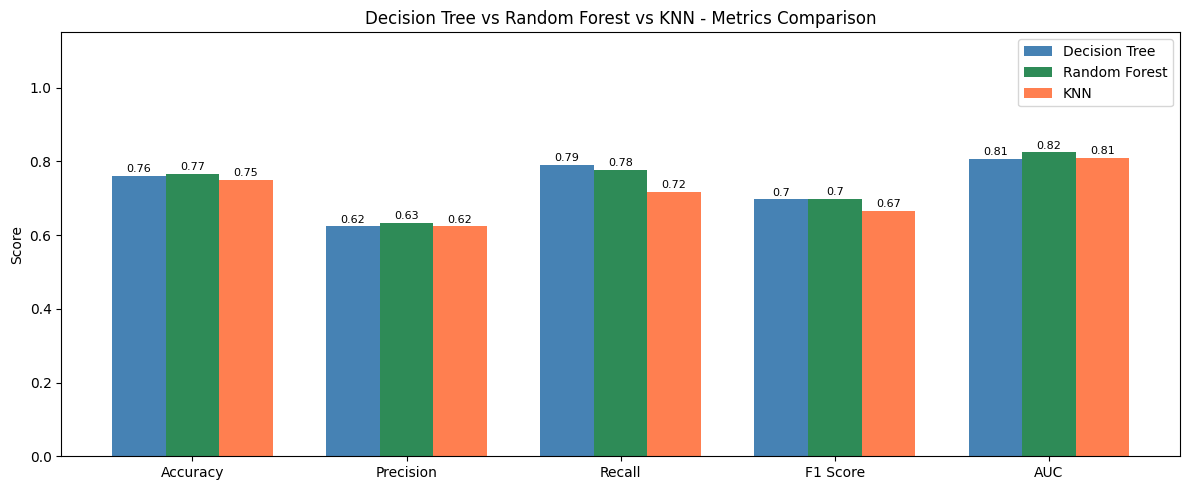

In [ ]:
dt_accuracy  = accuracy_score(Y_test, y_pred_dt)
dt_precision = metrics.precision_score(Y_test, y_pred_dt)
dt_recall    = metrics.recall_score(Y_test, y_pred_dt)
dt_f1        = metrics.f1_score(Y_test, y_pred_dt)

rf_accuracy  = accuracy_score(Y_test, y_pred_rf)
rf_precision = metrics.precision_score(Y_test, y_pred_rf)
rf_recall    = metrics.recall_score(Y_test, y_pred_rf)
rf_f1        = metrics.f1_score(Y_test, y_pred_rf)

knn_accuracy  = accuracy_score(Y_test, y_pred_knn)
knn_precision = metrics.precision_score(Y_test, y_pred_knn)
knn_recall    = metrics.recall_score(Y_test, y_pred_knn)
knn_f1        = metrics.f1_score(Y_test, y_pred_knn)

auc_rf = roc_auc_score(Y_test, y_prob_rf)

# Print comparison table
print("========== Final Comparison ==========")
print(f"{'Metric':<15} {'Decision Tree':>15} {'Random Forest':>15} {'KNN':>10}")
print("-" * 57)
print(f"{'Accuracy':<15} {dt_accuracy:>15.4f} {rf_accuracy:>15.4f} {knn_accuracy:>10.4f}")
print(f"{'Precision':<15} {dt_precision:>15.4f} {rf_precision:>15.4f} {knn_precision:>10.4f}")
print(f"{'Recall':<15} {dt_recall:>15.4f} {rf_recall:>15.4f} {knn_recall:>10.4f}")
print(f"{'F1 Score':<15} {dt_f1:>15.4f} {rf_f1:>15.4f} {knn_f1:>10.4f}")
print(f"{'AUC Score':<15} {auc_dt:>15.4f} {auc_rf:>15.4f} {auc_knn:>10.4f}")

# Bar chart comparing all 3
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC']
dt_scores  = [dt_accuracy,  dt_precision,  dt_recall,  dt_f1,  auc_dt]
rf_scores  = [rf_accuracy,  rf_precision,  rf_recall,  rf_f1,  auc_rf]
knn_scores = [knn_accuracy, knn_precision, knn_recall, knn_f1, auc_knn]

x     = np.arange(len(metric_names))
width = 0.25

plt.figure(figsize=(12, 5))
plt.bar(x - width, dt_scores,  width, label='Decision Tree',  color='steelblue')
plt.bar(x,         rf_scores,  width, label='Random Forest',  color='seagreen')
plt.bar(x + width, knn_scores, width, label='KNN',            color='coral')
plt.xticks(x, metric_names)
plt.ylabel('Score')
plt.ylim(0, 1.15)
plt.title('Decision Tree vs Random Forest vs KNN - Metrics Comparison')
plt.legend()

for i, (dt, rf, knn) in enumerate(zip(dt_scores, rf_scores, knn_scores)):
    plt.text(i - width, dt  + 0.01, str(round(dt,  2)), ha='center', fontsize=8)
    plt.text(i,         rf  + 0.01, str(round(rf,  2)), ha='center', fontsize=8)
    plt.text(i + width, knn + 0.01, str(round(knn, 2)), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# Detailed Comparison Table
models = ['Decision Tree', 'Random Forest', 'KNN']

accuracy_list = [dt_accuracy, rf_accuracy, knn_accuracy]
f1_list = [dt_f1, rf_f1, knn_f1]

comparison_df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracy_list,
    'F1 Score': f1_list
})

print(comparison_df)

           Model  Accuracy  F1 Score
0  Decision Tree  0.760417  0.697368
1  Random Forest  0.765625  0.697987
2            KNN  0.750000  0.666667


In [ ]:
# Re-define Decision Tree Model for Cross-Validation
dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42)

dt.fit(X_train, Y_train)


DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, min_samples_split=10,
                       random_state=42)

In [ ]:
# Cross Validation (Model Stability Check)

from sklearn.model_selection import cross_val_score

cv_dt = cross_val_score(dt, X, Y, cv=5)
cv_knn = cross_val_score(knn_model, X, Y, cv=5)

print("DT CV Mean:", cv_dt.mean(), "STD:", cv_dt.std())
print("KNN CV Mean:", cv_knn.mean(), "STD:", cv_knn.std())

DT CV Mean: 0.7487479840421016 STD: 0.03342062072295906
KNN CV Mean: 0.7383413971649266 STD: 0.040225028726869456


In [ ]:
# Save Models
import joblib

joblib.dump(dt, 'decision_tree_model.pkl')
joblib.dump(rf_model, 'random_forest_model.pkl')
joblib.dump(knn_model, 'knn_model.pkl')

print("Models saved successfully")

Models saved successfully


In [ ]:
import joblib
joblib.dump(dt, 'decision_tree_model.pkl')

['decision_tree_model.pkl']

In [ ]:
# Load Model and Test Prediction
loaded_model = joblib.load('random_forest_model.pkl')

sample = X_test[0].reshape(1, -1)
prediction = loaded_model.predict(sample)

print("Sample Prediction:", prediction)

Sample Prediction: [1]


In [ ]:
# Test on new sample
sample = X_test[0].reshape(1, -1)

print("DT Prediction:", dt.predict(sample))
print("RF Prediction:", rf_model.predict(sample))
print("KNN Prediction:", knn_model.predict(sample))

DT Prediction: [1]
RF Prediction: [1]
KNN Prediction: [1]
